# 04 Modelado supervisado — Random Forest, XGBoost y SHAP

**Proyecto:** Siniestros fatales de tránsito en el Perú 2021-2025  
**Curso:** Agentes Inteligentes | Grupo 5

Este notebook toma los datasets generados en el notebook 03 y entrena modelos supervisados para clasificar la severidad del siniestro. La evaluación se realiza sobre test sin SMOTE, de modo que las métricas reflejen la distribución real del problema.

## 0. Configuración

El notebook puede ejecutarse desde la raíz del repositorio o desde la carpeta `notebooks/`.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

try:
    from xgboost import XGBClassifier
    XGBOOST_DISPONIBLE = True
except ImportError:
    XGBOOST_DISPONIBLE = False
    print('XGBoost no está instalado. Ejecutar: pip install xgboost')

try:
    import shap
    SHAP_DISPONIBLE = True
except ImportError:
    SHAP_DISPONIBLE = False
    print('SHAP no está instalado. Ejecutar: pip install shap')

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent

DATA_PROC = ROOT / 'data' / 'procesada'
DIR_FIGURAS = ROOT / 'outputs' / 'figures'
DIR_TABLAS = ROOT / 'outputs' / 'tablas'
DIR_FIGURAS.mkdir(parents=True, exist_ok=True)
DIR_TABLAS.mkdir(parents=True, exist_ok=True)

TARGET = 'CATEGORIA_SEVERIDAD'
TARGET_ENC = 'CATEGORIA_SEVERIDAD_ENC'
RANDOM_STATE = 42

## 1. Carga de datos

Se usa `siniestros_train.csv` para entrenar y `siniestros_test.csv` para evaluar. Si el archivo de test fue generado con desalineación de índices, se reconstruye el split desde `siniestros_modelado.csv` usando los mismos parámetros del notebook 03.

In [2]:
path_train = DATA_PROC / 'siniestros_train.csv'
path_test = DATA_PROC / 'siniestros_test.csv'
path_modelado = DATA_PROC / 'siniestros_modelado.csv'

for path in [path_train, path_test, path_modelado]:
    if not path.exists():
        raise FileNotFoundError(f'No se encontró {path}. Ejecutar primero el notebook 03.')

train_df = pd.read_csv(path_train, encoding='utf-8-sig')
test_df = pd.read_csv(path_test, encoding='utf-8-sig')
modelado_df = pd.read_csv(path_modelado, encoding='utf-8-sig')

for df in [train_df, test_df, modelado_df]:
    df.columns = [str(c).replace('\ufeff', '').strip() for c in df.columns]

print(f'Train cargado: {train_df.shape[0]:,} filas x {train_df.shape[1]} columnas')
print(f'Test cargado:  {test_df.shape[0]:,} filas x {test_df.shape[1]} columnas')
print(f'Completo sin SMOTE: {modelado_df.shape[0]:,} filas x {modelado_df.shape[1]} columnas')

Train cargado: 18,363 filas x 46 columnas
Test cargado:  3,263 filas x 46 columnas
Completo sin SMOTE: 9,106 filas x 46 columnas


In [3]:
def validar_dataset_modelado(df, nombre):
    faltantes = [c for c in [TARGET, TARGET_ENC] if c not in df.columns]
    if faltantes:
        raise KeyError(f'{nombre} no contiene columnas requeridas: {faltantes}')
    n_target_nulo = df[TARGET_ENC].isna().sum()
    n_features_nulas = df.drop(columns=[TARGET, TARGET_ENC], errors='ignore').isna().any(axis=1).sum()
    print(f'{nombre}: target nulo={n_target_nulo:,} | filas con features nulas={n_features_nulas:,}')
    return n_target_nulo == 0 and n_features_nulas == 0

train_ok = validar_dataset_modelado(train_df, 'train')
test_ok = validar_dataset_modelado(test_df, 'test')

if not test_ok:
    print('\nSe reconstruye el test desde siniestros_modelado.csv con split estratificado 80/20.')
    X_full = modelado_df.drop(columns=[TARGET, TARGET_ENC])
    y_full = modelado_df[TARGET_ENC].astype(int)
    _, X_test_rec, _, y_test_rec = train_test_split(
        X_full,
        y_full,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=y_full,
    )
    test_df = X_test_rec.reset_index(drop=True).copy()
    test_df[TARGET_ENC] = y_test_rec.to_numpy()
    mapa_clases = (
        modelado_df[[TARGET, TARGET_ENC]]
        .dropna()
        .drop_duplicates()
        .assign(**{TARGET_ENC: lambda d: d[TARGET_ENC].astype(int)})
        .sort_values(TARGET_ENC)
        .set_index(TARGET_ENC)[TARGET]
        .to_dict()
    )
    test_df[TARGET] = test_df[TARGET_ENC].map(mapa_clases)
    print(f'Test reconstruido: {test_df.shape[0]:,} filas x {test_df.shape[1]} columnas')

if not train_ok:
    train_df = train_df.dropna(subset=[TARGET, TARGET_ENC]).dropna().reset_index(drop=True)
    print(f'Train depurado: {train_df.shape[0]:,} filas')

train: target nulo=0 | filas con features nulas=0
test: target nulo=1,441 | filas con features nulas=1,441

Se reconstruye el test desde siniestros_modelado.csv con split estratificado 80/20.
Test reconstruido: 1,822 filas x 46 columnas


## 2. Separación de X e y

In [4]:
X_train = train_df.drop(columns=[TARGET, TARGET_ENC])
y_train = train_df[TARGET_ENC].astype(int)

X_test = test_df.drop(columns=[TARGET, TARGET_ENC])
y_test = test_df[TARGET_ENC].astype(int)

class_map = (
    pd.concat([
        train_df[[TARGET, TARGET_ENC]],
        test_df[[TARGET, TARGET_ENC]],
    ])
    .dropna()
    .drop_duplicates()
    .assign(**{TARGET_ENC: lambda d: d[TARGET_ENC].astype(int)})
    .sort_values(TARGET_ENC)
    .set_index(TARGET_ENC)[TARGET]
    .to_dict()
)
class_names = [class_map[i] for i in sorted(class_map)]

print(f'X_train: {X_train.shape}')
print(f'X_test:  {X_test.shape}')
print(f'Clases: {class_map}')
print('\nDistribución train:')
print(y_train.value_counts().sort_index())
print('\nDistribución test:')
print(y_test.value_counts().sort_index())

X_train: (18363, 44)
X_test:  (1822, 44)
Clases: {0: 'GRAVE_LESIONADOS', 1: 'GRAVE_MORTALIDAD', 2: 'LEVE'}

Distribución train:
CATEGORIA_SEVERIDAD_ENC
0    6121
1    6121
2    6121
Name: count, dtype: int64

Distribución test:
CATEGORIA_SEVERIDAD_ENC
0     105
1     186
2    1531
Name: count, dtype: int64


## 3. Funciones de evaluación

In [5]:
def evaluar_modelo(nombre, modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test) if hasattr(modelo, 'predict_proba') else None

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_test, y_pred, average='macro', zero_division=0
    )
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_test, y_pred, average='weighted', zero_division=0
    )

    try:
        roc_auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro') if y_proba is not None else np.nan
    except ValueError:
        roc_auc = np.nan

    metricas = {
        'modelo': nombre,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision_macro': precision_macro,
        'recall_macro': recall_macro,
        'f1_macro': f1_macro,
        'precision_weighted': precision_weighted,
        'recall_weighted': recall_weighted,
        'f1_weighted': f1_weighted,
        'roc_auc_ovr_macro': roc_auc,
    }

    print(f'=== {nombre} ===')
    print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))
    return metricas, y_pred, y_proba

def guardar_matriz_confusion(nombre_archivo, y_true, y_pred, titulo):
    cm = confusion_matrix(y_true, y_pred, labels=sorted(class_map))
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(titulo)
    plt.xlabel('Predicción')
    plt.ylabel('Clase real')
    plt.tight_layout()
    plt.savefig(DIR_FIGURAS / nombre_archivo, dpi=150)
    plt.show()

def guardar_importancias(nombre_modelo, modelo, columnas):
    if not hasattr(modelo, 'feature_importances_'):
        return None
    imp = pd.DataFrame({
        'feature': columnas,
        'importancia': modelo.feature_importances_,
    }).sort_values('importancia', ascending=False)
    imp.to_csv(DIR_TABLAS / f'importancias_{nombre_modelo}.csv', index=False, encoding='utf-8')

    top = imp.head(15).sort_values('importancia')
    plt.figure(figsize=(9, 6))
    plt.barh(top['feature'], top['importancia'], color='#2f6f8f')
    plt.title(f'Top 15 variables — {nombre_modelo}')
    plt.xlabel('Importancia')
    plt.tight_layout()
    plt.savefig(DIR_FIGURAS / f'importancias_{nombre_modelo}.png', dpi=150)
    plt.show()
    return imp

## 4. Modelo base: Random Forest

=== Random Forest ===
                  precision    recall  f1-score   support

GRAVE_LESIONADOS       0.12      0.07      0.09       105
GRAVE_MORTALIDAD       0.25      0.25      0.25       186
            LEVE       0.88      0.90      0.89      1531

        accuracy                           0.79      1822
       macro avg       0.42      0.41      0.41      1822
    weighted avg       0.77      0.79      0.78      1822



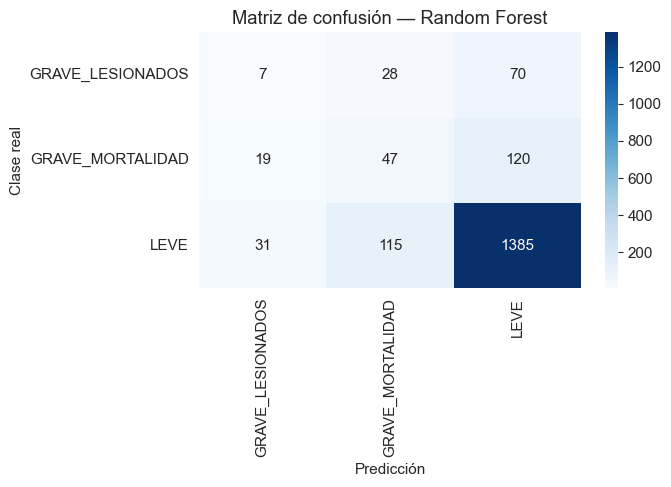

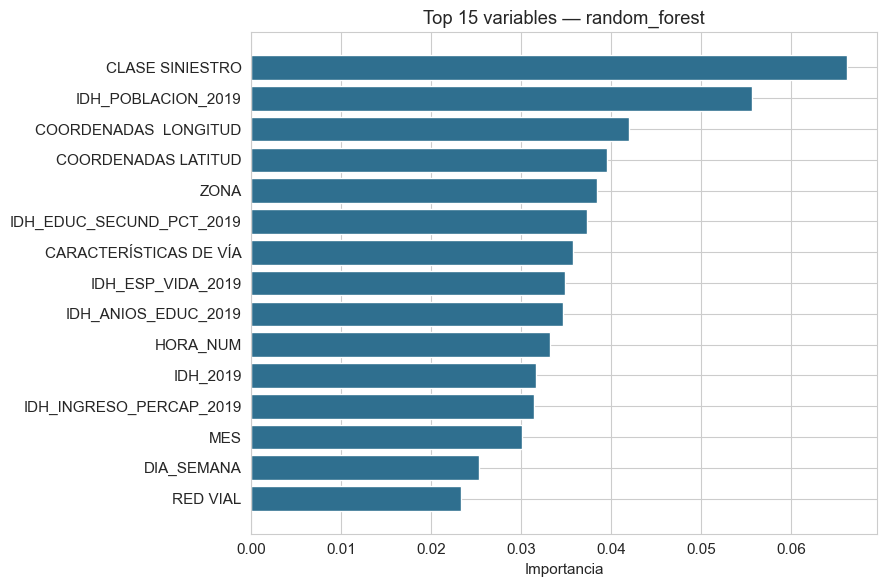

In [6]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

rf.fit(X_train, y_train)
metricas_rf, y_pred_rf, y_proba_rf = evaluar_modelo('Random Forest', rf, X_test, y_test)
guardar_matriz_confusion('confusion_random_forest.png', y_test, y_pred_rf, 'Matriz de confusión — Random Forest')
importancias_rf = guardar_importancias('random_forest', rf, X_train.columns)

## 5. Modelo comparativo: XGBoost

=== XGBoost ===
                  precision    recall  f1-score   support

GRAVE_LESIONADOS       0.19      0.10      0.13       105
GRAVE_MORTALIDAD       0.26      0.23      0.25       186
            LEVE       0.87      0.91      0.89      1531

        accuracy                           0.80      1822
       macro avg       0.44      0.41      0.42      1822
    weighted avg       0.77      0.80      0.78      1822



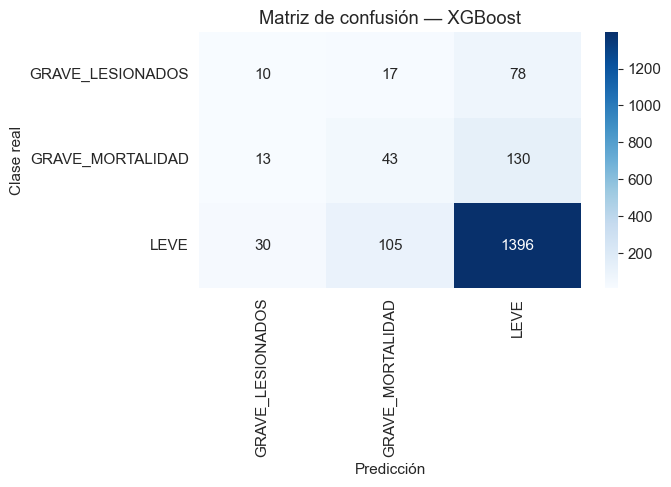

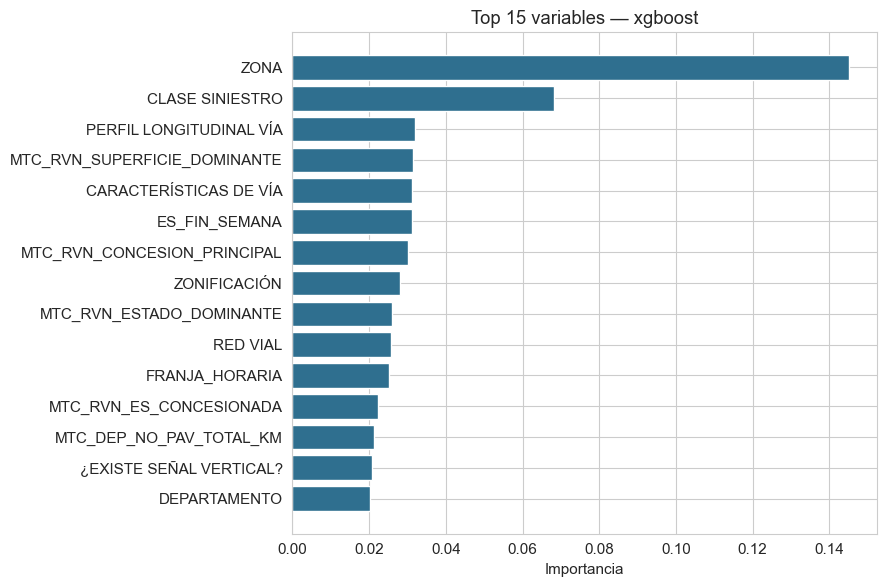

In [7]:
modelos = {'Random Forest': rf}
metricas = [metricas_rf]

if XGBOOST_DISPONIBLE:
    xgb = XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='multi:softprob',
        eval_metric='mlogloss',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    xgb.fit(X_train, y_train)
    metricas_xgb, y_pred_xgb, y_proba_xgb = evaluar_modelo('XGBoost', xgb, X_test, y_test)
    guardar_matriz_confusion('confusion_xgboost.png', y_test, y_pred_xgb, 'Matriz de confusión — XGBoost')
    importancias_xgb = guardar_importancias('xgboost', xgb, X_train.columns)
    modelos['XGBoost'] = xgb
    metricas.append(metricas_xgb)
else:
    xgb = None
    importancias_xgb = None
    print('Se omite XGBoost porque no está instalado.')

## 6. Comparación de modelos

Para este problema se prioriza `f1_macro` y `recall_macro`, porque las clases graves son minoritarias y no conviene elegir un modelo solo por accuracy.

In [8]:
metricas_df = pd.DataFrame(metricas).sort_values('f1_macro', ascending=False)
metricas_df.to_csv(DIR_TABLAS / 'metricas_modelos.csv', index=False, encoding='utf-8')
metricas_df

,modelo,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,roc_auc_ovr_macro
1,XGBoost,0.795280,0.439870,0.412748,0.420729,0.768798,0.795280,0.780657,0.759064
0,Random Forest,0.789791,0.416514,0.407997,0.409414,0.771248,0.789791,0.779887,0.747367


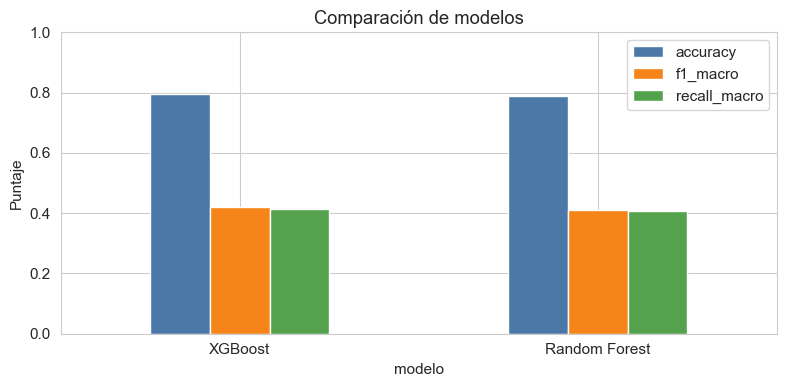

Mejor modelo según F1 macro: XGBoost


In [9]:
plt.figure(figsize=(8, 4))
metricas_plot = metricas_df.set_index('modelo')[['accuracy', 'f1_macro', 'recall_macro']]
metricas_plot.plot(kind='bar', ax=plt.gca(), color=['#4c78a8', '#f58518', '#54a24b'])
plt.title('Comparación de modelos')
plt.ylabel('Puntaje')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(DIR_FIGURAS / 'comparacion_modelos.png', dpi=150)
plt.show()

mejor_nombre = metricas_df.iloc[0]['modelo']
mejor_modelo = modelos[mejor_nombre]
print(f'Mejor modelo según F1 macro: {mejor_nombre}')

## 7. Interpretabilidad con SHAP

SHAP permite explicar qué variables empujan las predicciones del modelo. Se usa una muestra del test para mantener el cálculo manejable.

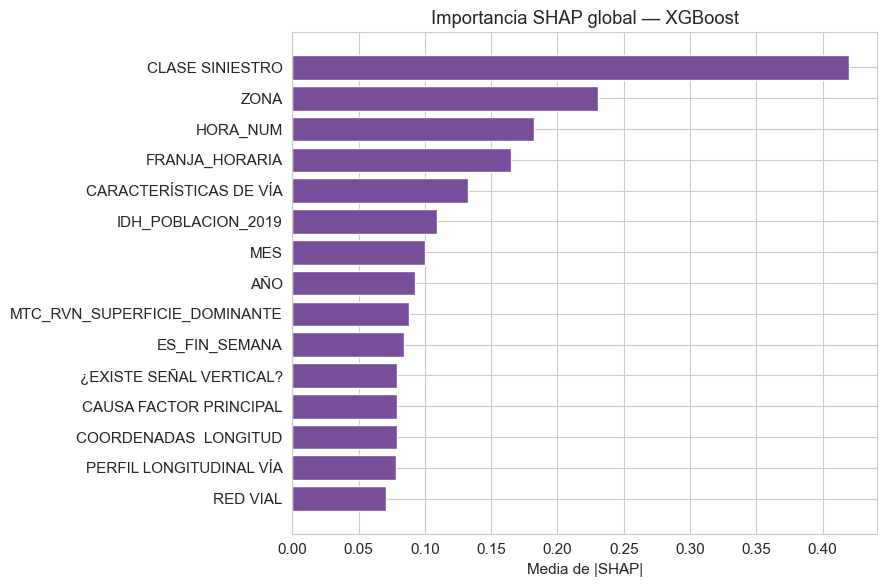

In [10]:
if SHAP_DISPONIBLE:
    X_shap = X_test.sample(n=min(500, len(X_test)), random_state=RANDOM_STATE)
    explainer = shap.TreeExplainer(mejor_modelo)
    shap_values = explainer.shap_values(X_shap)

    if isinstance(shap_values, list):
        shap_arr = np.stack(shap_values, axis=-1)
    else:
        shap_arr = np.asarray(shap_values)
        if shap_arr.ndim == 3 and shap_arr.shape[1] != X_shap.shape[1]:
            shap_arr = np.transpose(shap_arr, (1, 2, 0))

    if shap_arr.ndim == 3:
        importancia_shap = np.abs(shap_arr).mean(axis=(0, 2))
    else:
        importancia_shap = np.abs(shap_arr).mean(axis=0)

    shap_imp = pd.DataFrame({
        'feature': X_shap.columns,
        'importancia_shap_media_abs': importancia_shap,
    }).sort_values('importancia_shap_media_abs', ascending=False)
    shap_imp.to_csv(DIR_TABLAS / 'importancia_shap.csv', index=False, encoding='utf-8')

    top = shap_imp.head(15).sort_values('importancia_shap_media_abs')
    plt.figure(figsize=(9, 6))
    plt.barh(top['feature'], top['importancia_shap_media_abs'], color='#7a4f9a')
    plt.title(f'Importancia SHAP global — {mejor_nombre}')
    plt.xlabel('Media de |SHAP|')
    plt.tight_layout()
    plt.savefig(DIR_FIGURAS / 'shap_importancia_global.png', dpi=150)
    plt.show()

    shap_imp.head(15)
else:
    shap_imp = None
    print('Se omite SHAP porque no está instalado.')

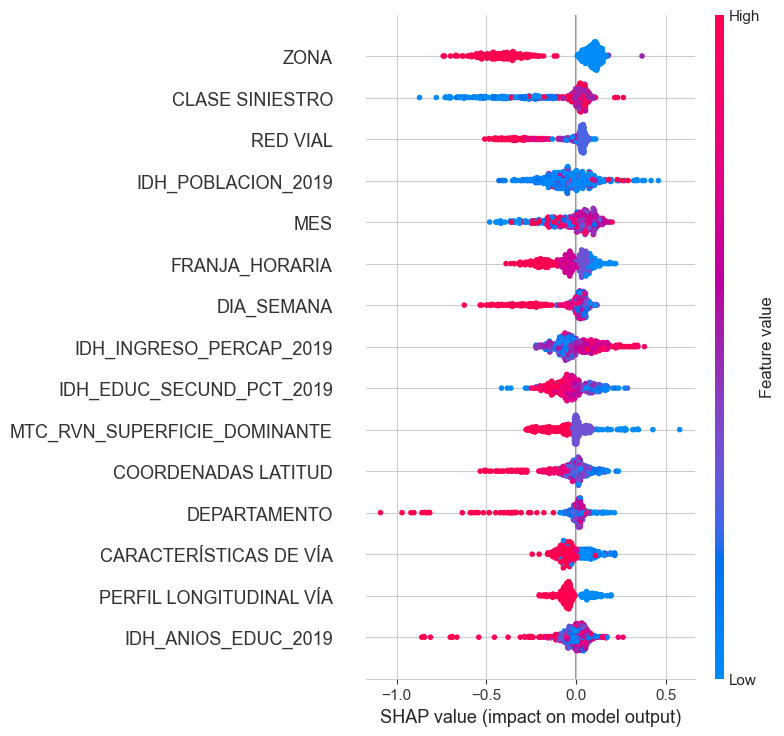

In [11]:
if SHAP_DISPONIBLE:
    plt.figure()
    try:
        if isinstance(shap_values, list):
            shap.summary_plot(shap_values, X_shap, class_names=class_names, max_display=15, show=False)
        elif np.asarray(shap_values).ndim == 2:
            shap.summary_plot(shap_values, X_shap, max_display=15, show=False)
        else:
            clase_grave = next((idx for idx, nombre in class_map.items() if nombre == 'GRAVE_MORTALIDAD'), sorted(class_map)[0])
            pos_clase = sorted(class_map).index(clase_grave)
            shap.summary_plot(shap_arr[:, :, pos_clase], X_shap, max_display=15, show=False)
        plt.tight_layout()
        plt.savefig(DIR_FIGURAS / 'shap_summary.png', dpi=150, bbox_inches='tight')
        plt.show()
    except Exception as e:
        print(f'No se pudo generar shap.summary_plot: {e}')

## 8. Conclusión del notebook

In [12]:
print('Conclusión metodológica:')
print(f'- Se entrenó con train balanceado por SMOTE: {len(X_train):,} registros.')
print(f'- Se evaluó con test sin SMOTE: {len(X_test):,} registros.')
print(f'- El mejor modelo según F1 macro fue: {mejor_nombre}.')
print('- Las métricas principales se guardaron en outputs/tablas/metricas_modelos.csv.')
print('- Las matrices de confusión, comparación e interpretabilidad se guardaron en outputs/figures/.')

Conclusión metodológica:
- Se entrenó con train balanceado por SMOTE: 18,363 registros.
- Se evaluó con test sin SMOTE: 1,822 registros.
- El mejor modelo según F1 macro fue: XGBoost.
- Las métricas principales se guardaron en outputs/tablas/metricas_modelos.csv.
- Las matrices de confusión, comparación e interpretabilidad se guardaron en outputs/figures/.


## Referencias metodológicas

- **Breiman (2001)** — Random Forest como modelo base de ensamble.
- **Chen et al. (2025)** — XGBoost e interpretabilidad SHAP para severidad vial.
- **Bazarnovi y Mohammadian (2024)** — evaluación con datos desbalanceados y uso de SMOTE.
- **Géron (2022)** — evaluación supervisada con separación train/test.